In [9]:
# Customer Churn Analysis & Prediction

## Business Problem
# The goal of this project is to identify the main drivers of customer churn and build a predictive model to help the company reduce customer loss.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv(r"C:\Users\jovau\customer-churn-analysis\data\WA_Fn-UseC_-Telco-Customer-Churn.csv")  # load dataset

df.head()  # show first 5 rows

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [12]:
# DATA CLEANING

# convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# remove missing values
df = df.dropna()

# convert Churn to numeric
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# drop unnecessary ID column
df = df.drop("customerID", axis=1, errors="ignore")

df.info()  # confirm cleaned data

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   str    
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   str    
 3   Dependents        7032 non-null   str    
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   str    
 6   MultipleLines     7032 non-null   str    
 7   InternetService   7032 non-null   str    
 8   OnlineSecurity    7032 non-null   str    
 9   OnlineBackup      7032 non-null   str    
 10  DeviceProtection  7032 non-null   str    
 11  TechSupport       7032 non-null   str    
 12  StreamingTV       7032 non-null   str    
 13  StreamingMovies   7032 non-null   str    
 14  Contract          7032 non-null   str    
 15  PaperlessBilling  7032 non-null   str    
 16  PaymentMethod     7032 non-null   str    
 17  MonthlyChar

In [ ]:
## Exploratory Data Analysis

In [13]:
#Churn Distribution

df["Churn"].value_counts()


Churn
0    5163
1    1869
Name: count, dtype: int64

In [14]:
df["Churn"].value_counts(normalize=True) * 100

Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64

In [29]:
# Churn by Contract
contract = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
contract.columns = ["No Churn", "Churn"]
contract.round(0).astype(int).astype(str) + "%"

,No Churn,Churn
Contract,,
Month-to-month,57%,43%
One year,89%,11%
Two year,97%,3%


In [30]:
# Churn by Payment Method
payment = pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100
payment.columns = ["No Churn", "Churn"]
payment.round(0).astype(int).astype(str) + "%"

,No Churn,Churn
PaymentMethod,,
Bank transfer (automatic),83%,17%
Credit card (automatic),85%,15%
Electronic check,55%,45%
Mailed check,81%,19%


In [31]:
# avg charges by churn
df.groupby("Churn")["MonthlyCharges"].mean() .round(2) .astype(int).astype(str) + "%"

Churn
0    61%
1    74%
Name: MonthlyCharges, dtype: str

In [35]:
# churn percentage by payment method
table = pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100

table.columns = ["No Churn", "Churn"]

(table.round(0).astype(int).astype(str) + "%")

,No Churn,Churn
PaymentMethod,,
Bank transfer (automatic),83%,17%
Credit card (automatic),85%,15%
Electronic check,55%,45%
Mailed check,81%,19%


In [36]:
# churn percentage by internet service
table = pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100

table.columns = ["No Churn", "Churn"]

(table.round(0).astype(int).astype(str) + "%")

,No Churn,Churn
InternetService,,
DSL,81%,19%
Fiber optic,58%,42%
No,93%,7%


In [22]:
# average charges and tenure
df.groupby("Churn")[["MonthlyCharges", "tenure"]].mean().round(2)

,MonthlyCharges,tenure
Churn,,
0,61.31,37.65
1,74.44,17.98


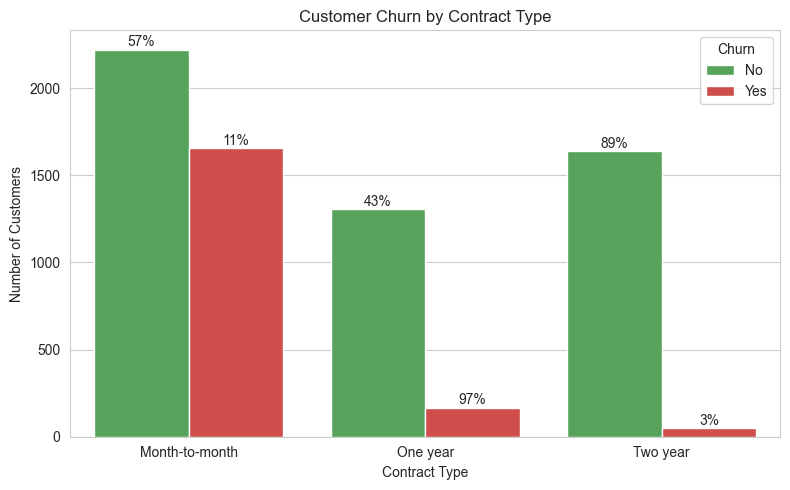

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# style
sns.set_style("whitegrid")
plt.figure(figsize=(8, 5))

# plot
ax = sns.countplot(
    x="Contract",
    hue="Churn",
    data=df,
    palette=["#4CAF50", "#E53935"]
)

# calculate percentages
percent = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100

# add labels to bars
for i, contract in enumerate(percent.index):
    for j, churn_value in enumerate(percent.columns):
        bar = ax.patches[i * 2 + j]
        height = bar.get_height()
        value = percent.loc[contract, churn_value]

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 20,
            f"{value:.0f}%",
            ha="center"
        )

# labels
plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.legend(title="Churn", labels=["No", "Yes"])

plt.tight_layout()
plt.show()

                                                    
                                                    Prepare Data for Machine Learning

In [24]:
# convert text to numbers
df_model = pd.get_dummies(df, drop_first=True)

# split features and target
X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# train model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# predictions
y_pred = model.predict(X_test)
# ----------------------------------
# IMPROVE MODEL (ADJUST THRESHOLD)
# ----------------------------------

# get probability of churn
y_prob = model.predict_proba(X_test)[:, 1]

# lower threshold (from 0.5 → 0.3)
y_pred_custom = (y_prob > 0.3).astype(int)

# evaluate new predictions
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.87      0.77      0.81      1011
           1       0.54      0.70      0.61       396

    accuracy                           0.75      1407
   macro avg       0.70      0.73      0.71      1407
weighted avg       0.77      0.75      0.76      1407



In [58]:
from sklearn.metrics import accuracy_score, confusion_matrix

# accuracy
accuracy = accuracy_score(y_test, y_pred) * 100
print("Accuracy:", round(accuracy), "%")

# confusion matrix
print(confusion_matrix(y_test, y_pred))

Accuracy: 79 %
[[922  89]
 [207 189]]


In [59]:
# factors  that actually drives churn?


feature_importance = pd.Series(model.feature_importances_, index=X.columns)

# sort from highest to lowest
feature_importance = feature_importance.sort_values(ascending=False)

feature_importance.head(10)  # top 10 features

TotalCharges                      0.194562
tenure                            0.169951
MonthlyCharges                    0.168464
InternetService_Fiber optic       0.039483
PaymentMethod_Electronic check    0.035442
OnlineSecurity_Yes                0.028744
gender_Male                       0.027792
Contract_Two year                 0.027121
PaperlessBilling_Yes              0.025141
TechSupport_Yes                   0.024656
dtype: float64

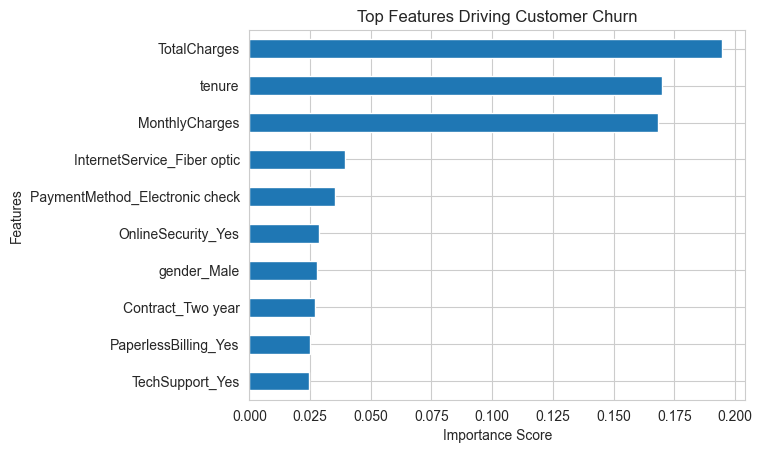

In [60]:
# plot feature importance

# get top 10 features
top_features = feature_importance.head(10)

# plot
top_features.plot(kind="barh")

plt.title("Top Features Driving Customer Churn")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.gca().invert_yaxis()
plt.show()

## Churn Prediction (Application)

This section uses the trained model to predict churn and identify high-risk customers.

In [61]:
# predict churn (0 or 1)
predictions = model.predict(X_test)

In [62]:
# probability of churn (1)
probabilities = model.predict_proba(X_test)[:, 1]

In [63]:
# count risk levels
results["Risk_Level"].value_counts()

Risk_Level
Low       1029
Medium     253
High       125
Name: count, dtype: int64

In [64]:
# classify risk level
results["Risk_Level"] = results["Churn_Probability"].apply(
    lambda x: "High" if x > 0.7 else "Medium" if x > 0.4 else "Low"
)

results.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Actual,Predicted,Churn_Probability,Risk_Level
169,0,16,20.4,321.40,False,True,True,True,False,False,...,False,False,False,False,True,False,0,0,0.03,Low
2539,0,65,26.0,1654.85,False,True,True,True,False,True,...,False,True,False,True,False,False,0,0,0.00,Low
994,0,13,20.0,268.45,True,False,False,True,False,False,...,False,True,False,True,False,False,0,0,0.00,Low
3362,0,1,54.9,54.90,False,False,False,True,False,False,...,False,False,True,False,True,False,1,1,0.53,Medium
4434,0,16,90.7,1374.90,False,True,False,True,False,True,...,False,False,False,False,True,False,0,1,0.58,Medium


In [65]:
# high-risk customers
high_risk = results[results["Risk_Level"] == "High"]

high_risk.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Actual,Predicted,Churn_Probability,Risk_Level
5868,0,1,44.00,44.00,False,False,False,True,False,False,...,False,False,True,False,False,True,0,1,0.82,High
5341,1,1,74.45,74.45,False,False,False,True,False,True,...,False,False,True,False,False,True,1,1,0.78,High
3885,0,3,74.95,212.40,False,False,False,True,False,True,...,False,False,True,False,True,False,0,1,0.95,High
2465,0,1,35.25,35.25,True,False,False,False,True,False,...,False,False,True,False,False,False,1,1,0.76,High
6846,0,1,79.55,79.55,False,False,False,True,False,True,...,False,False,True,False,False,True,1,1,0.76,High


In [66]:
# top 10 highest risk customers
high_risk.sort_values(by="Churn_Probability", ascending=False).head(10)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Actual,Predicted,Churn_Probability,Risk_Level
4084,0,1,78.05,78.05,False,False,False,True,False,False,...,False,False,False,False,True,False,1,1,0.99,High
3349,0,11,99.50,1056.95,False,True,False,True,False,True,...,False,False,True,False,True,False,1,1,0.99,High
2631,1,7,99.25,665.45,True,True,False,True,False,True,...,False,False,True,False,True,False,1,1,0.98,High
1807,0,1,76.35,76.35,False,False,False,True,False,False,...,False,False,False,False,True,False,1,1,0.98,High
2194,0,1,79.50,79.50,True,False,False,True,False,False,...,False,False,True,False,True,False,1,1,0.97,High
5640,0,1,79.60,79.60,True,False,False,True,False,False,...,False,False,False,False,True,False,1,1,0.97,High
1325,1,1,69.25,69.25,False,False,False,True,False,False,...,False,False,True,False,True,False,1,1,0.97,High
20,1,1,39.65,39.65,True,False,False,False,True,False,...,False,False,True,False,True,False,1,1,0.97,High
3346,1,2,84.05,186.05,False,False,False,True,False,True,...,False,False,True,False,True,False,0,1,0.96,High
2600,0,1,70.10,70.10,False,False,False,True,False,False,...,False,False,False,False,True,False,0,1,0.95,High



 ## Revenue & Customer Value Analysis

This section analyzes customer value and revenue contribution to identify high-value customers and potential revenue risk.

### Quick Insight

High-value customers generate the most revenue, and even a small churn rate in this group represents significant financial risk.

In [ ]:
# create revenue column
df["Revenue"] = df["MonthlyCharges"] * df["tenure"]           

df[["MonthlyCharges", "tenure", "Revenue"]].head()

#MonthlyCharges = monthly payment
#tenure = number of months
#Revenue = total value of customer

,MonthlyCharges,tenure,Revenue
0,29.85,1,29.85
1,56.95,34,1936.30
2,53.85,2,107.70
3,42.30,45,1903.50
4,70.70,2,141.40


In [5]:
# segment customers into 3 groups
df["Customer_Value"] = pd.qcut(
    df["Revenue"],
    q=3,
    labels=["Low", "Medium", "High"]
)

df["Customer_Value"].value_counts()

Customer_Value
Low       2349
High      2348
Medium    2346
Name: count, dtype: int64

### Customer Segmentation

Customers are grouped into Low, Medium, and High value based on total revenue.

In [10]:
# average revenue per segment
revenue_avg = df.groupby("Customer_Value")["Revenue"].mean().round(2)

revenue_avg = "$" + revenue_avg.astype(str)

revenue_avg

C:\Users\jovau\AppData\Local\Temp\ipykernel_25796\2818040846.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_avg = df.groupby("Customer_Value")["Revenue"].mean().round(2)


Customer_Value
Low        $245.13
Medium    $1497.38
High      $5096.44
Name: Revenue, dtype: object

In [ ]:
# churn percentage by customer value
value_churn = pd.crosstab(df["Customer_Value"], df["Churn"], normalize="index") * 100

value_churn.columns = ["No Churn", "Churn"]

value_churn = value_churn.round(0).astype(int).astype(str) + "%"

value_churn

## Low-value customers have the highest churn rate, while high-value customers are more stable.


,No Churn,Churn
Customer_Value,,
Low,61%,39%
Medium,76%,24%
High,83%,17%


Low-value customers have the highest churn rate, while high-value customers are more stable.

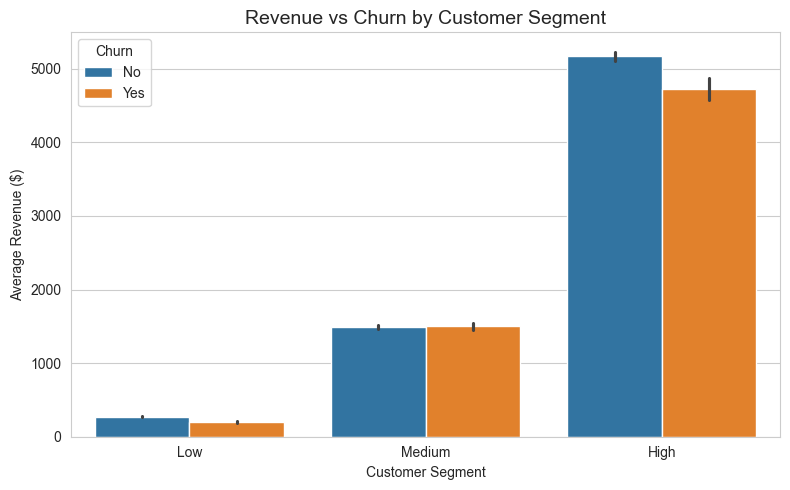

In [33]:
# total revenue at risk (churned customers)

sns.set_style("whitegrid")
plt.figure(figsize=(8,5))

sns.barplot(
    x="Customer_Value",
    y="Revenue",
    hue="Churn",
    data=df
)

plt.title("Revenue vs Churn by Customer Segment", fontsize=14)
plt.xlabel("Customer Segment")
plt.ylabel("Average Revenue ($)")

plt.legend(title="Churn")

plt.tight_layout()
plt.show()

High-value customers generate the most revenue, and even a small churn rate in this group represents significant financial risk.

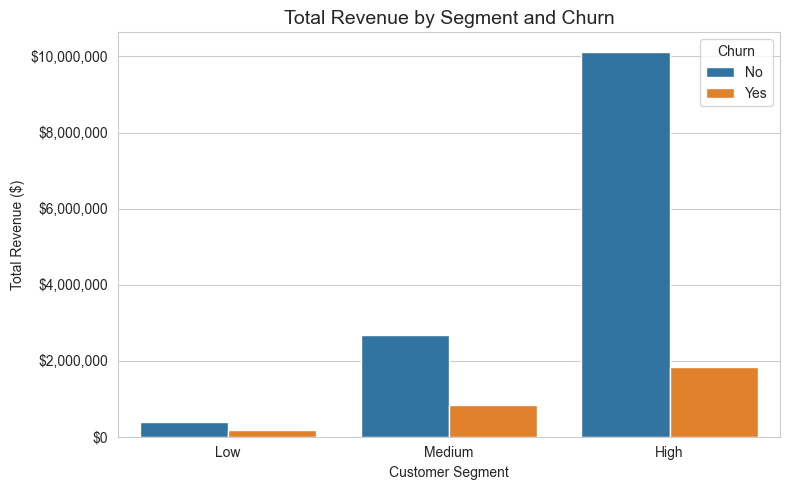

In [27]:
# visualize revenue by segment and churn
sns.set_style("whitegrid")
plt.figure(figsize=(8,5))

ax = sns.barplot(
    x="Customer_Value",
    y="Revenue",
    hue="Churn",
    data=df,
    estimator=sum,
    errorbar=None
)


ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

plt.title("Total Revenue by Segment and Churn", fontsize=14)
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue ($)")

plt.legend(title="Churn", labels=["No", "Yes"])

plt.tight_layout()
plt.show()
# High-value customers generate the most revenue, and even a small churn rate in this group represents significant financial risk.


This chart shows the total revenue contribution by each customer segment, highlighting where the majority of business value is concentrated.

In [32]:
# total revenue at risk (churned customers)
revenue_at_risk = df[df["Churn"] == "Yes"]["Revenue"].sum()
print(f"Total Revenue at Risk (Churned Customers): ${revenue_at_risk:,.0f}")

Total Revenue at Risk (Churned Customers): $2,862,577


### Revenue at Risk

This represents the total revenue associated with customers who have churned, highlighting the financial impact of customer loss.

In [34]:
# total revenue by segment (clean table)
df.groupby("Customer_Value")["Revenue"].sum().apply(lambda x: f"${x:,.0f}")

C:\Users\jovau\AppData\Local\Temp\ipykernel_25796\468576859.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Customer_Value")["Revenue"].sum().apply(lambda x: f"${x:,.0f}")


Customer_Value
Low          $575,817
Medium     $3,512,844
High      $11,966,430
Name: Revenue, dtype: object

### Key Business Insight

- High-value customers generate the majority of total revenue
- While their churn rate is lower, losing even a small number results in significant financial loss
- Low-value customers churn more frequently but have lower revenue impact
- Retention efforts should focus on protecting high-value customers